# Q1. Supervised Learning — Heart Disease Classification

This notebook loads `q1_heart_disease.csv`, performs exploratory analysis, preprocesses the data, trains three classifiers, evaluates them using classification metrics, and tunes the best-performing model.

**Data source:** GitHub raw file at `https://raw.githubusercontent.com/ritikadalela/ml-assessment-Ritika-Dalela/74af08cf34b00fde293ca57387128a8e5d244abe/Data/q1_heart_disease.csv`

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")
RANDOM_STATE = 42

## 1. Data Loading and Inspection

In [2]:
RAW_BASE_URL = "https://raw.githubusercontent.com/ritikadalela/ml-assessment-Ritika-Dalela/74af08cf34b00fde293ca57387128a8e5d244abe/Data"

def load_csv_from_github(filename):
    url = f"{RAW_BASE_URL}/{filename}"
    return pd.read_csv(url)

df = load_csv_from_github("q1_heart_disease.csv")
print("Loaded from:", f"{RAW_BASE_URL}/q1_heart_disease.csv")
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
df.head()


Loaded from: https://raw.githubusercontent.com/ritikadalela/ml-assessment-Ritika-Dalela/74af08cf34b00fde293ca57387128a8e5d244abe/Data/q1_heart_disease.csv
Shape: (800, 12)

Data types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


The dataset contains **800 rows and 12 columns**. Missing values appear in `resting_bp` and `cholesterol`, while the remaining fields are complete. Because these are numeric clinical measurements, median imputation is appropriate: it preserves sample size and is robust to skew and outliers that are common in medical data.

## 2. Exploratory Data Analysis

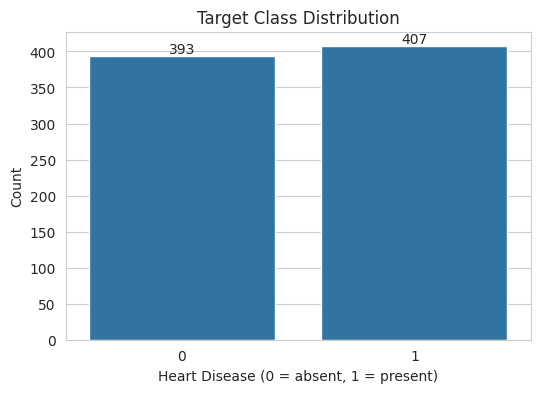

In [3]:
# Target class distribution
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='heart_disease')
ax.set_title('Target Class Distribution')
ax.set_xlabel('Heart Disease (0 = absent, 1 = present)')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

The target classes are **quite balanced**, which is helpful for supervised learning because the models will not be heavily biased toward a dominant class. That also means precision, recall, and F1-score are more informative than raw accuracy alone.

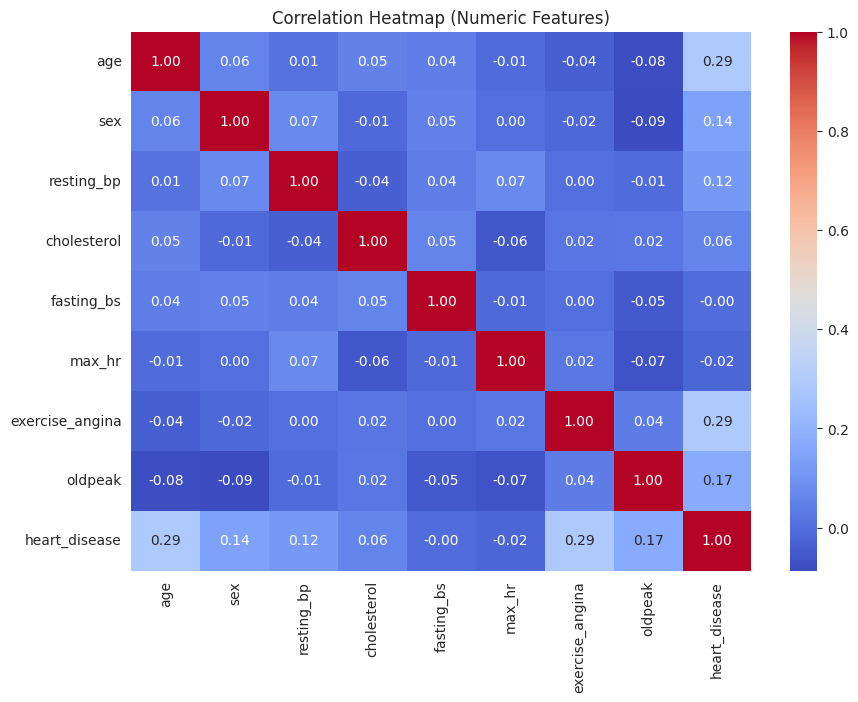

In [4]:
# Correlation heatmap for numeric variables
plt.figure(figsize=(10,7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

The heatmap shows that **`oldpeak` and `exercise_angina` are positively associated with heart disease**, while **`max_hr` is negatively associated**. This suggests that both exercise-related variables and ST depression may be meaningful predictive signals.

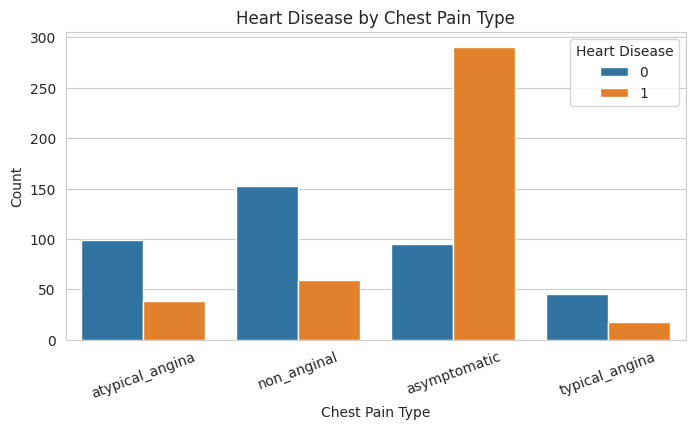

In [5]:
# Relationship between chest pain type and target
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='chest_pain_type', hue='heart_disease')
plt.title('Heart Disease by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.legend(title='Heart Disease')
plt.show()

Chest pain categories are not equally risky. In particular, some chest pain types appear to have a much higher proportion of positive heart disease cases, which supports one-hot encoding this categorical feature so models can learn category-specific effects.

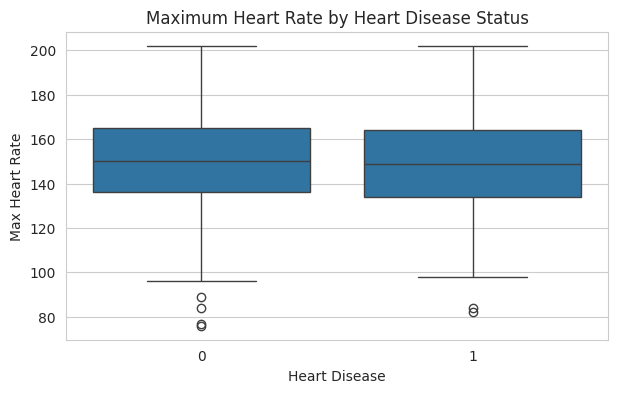

In [6]:
# Distribution of max heart rate by target
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='heart_disease', y='max_hr')
plt.title('Maximum Heart Rate by Heart Disease Status')
plt.xlabel('Heart Disease')
plt.ylabel('Max Heart Rate')
plt.show()

Patients with heart disease tend to have a **lower median maximum heart rate** than patients without heart disease. This aligns with the negative correlation observed earlier and suggests `max_hr` should contribute predictive value.

## 3. Data Preprocessing

### Missing-value strategy

I will use **median imputation** for numeric columns and **most-frequent imputation** for categorical columns. This is preferable to dropping rows because only two numeric columns contain missing values, and dropping rows would throw away useful data unnecessarily.

In [7]:
X = df.drop(columns=['heart_disease'])
y = df['heart_disease']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Numeric features: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']
Categorical features: ['chest_pain_type', 'resting_ecg', 'st_slope']
Train shape: (640, 11)
Test shape: (160, 11)


Categorical variables are one-hot encoded, numeric variables are standardised, and the split uses `stratify=y` with `random_state=42` as required. Fitting the preprocessing pipeline on the training data only avoids leakage from the test set.

## 4. Model Training

In [8]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

trained_models = {}
evaluation_rows = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    trained_models[name] = pipe
    evaluation_rows.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    })

    print(f"\n{'='*60}")
    print(name)
    print('='*60)
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

results_df = pd.DataFrame(evaluation_rows).sort_values('F1-score', ascending=False).reset_index(drop=True)
results_df


Decision Tree
Confusion Matrix:
[[56 23]
 [22 59]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7179    0.7089    0.7134        79
           1     0.7195    0.7284    0.7239        81

    accuracy                         0.7188       160
   macro avg     0.7187    0.7186    0.7187       160
weighted avg     0.7187    0.7188    0.7187       160


Random Forest
Confusion Matrix:
[[60 19]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8000    0.7595    0.7792        79
           1     0.7765    0.8148    0.7952        81

    accuracy                         0.7875       160
   macro avg     0.7882    0.7872    0.7872       160
weighted avg     0.7881    0.7875    0.7873       160


Gradient Boosting
Confusion Matrix:
[[61 18]
 [18 63]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7722    0.7722    0.7722        79
     

,Model,Precision,Recall,F1-score
0,Random Forest,0.776471,0.814815,0.795181
1,Gradient Boosting,0.777778,0.777778,0.777778
2,Decision Tree,0.719512,0.728395,0.723926


## 5. Model Evaluation

The **Random Forest** performs best on the untuned test set. Its **F1-score (~0.795)** is higher than Gradient Boosting (~0.778) and Decision Tree (~0.724), while also achieving the **highest recall (~0.815)**. That matters in this medical setting because missing patients who do have heart disease (false negatives) is costly. The Random Forest therefore offers the strongest balance between precision and recall, not just the highest overall correctness.

## 6. Hyperparameter Tuning

In [9]:
# Manual hyperparameter search (compact alternative to GridSearchCV)
search_space = [
    {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 2},
    {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 5},
    {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 2},
    {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 5},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 5},
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2},
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5},
]

cv_rows = []
best_score = -1
best_params = None

for params in search_space:
    candidate = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, **params))
    ])
    scores = cross_val_score(candidate, X_train, y_train, cv=3, scoring='f1', n_jobs=1)
    mean_score = scores.mean()

    row = params.copy()
    row['cv_f1'] = mean_score
    cv_rows.append(row)

    if mean_score > best_score:
        best_score = mean_score
        best_params = params

cv_results_df = pd.DataFrame(cv_rows).sort_values('cv_f1', ascending=False).reset_index(drop=True)
cv_results_df

,n_estimators,max_depth,min_samples_split,cv_f1
0,100,NaN,2,0.810813
1,100,NaN,5,0.807202
2,50,10.0,5,0.807010
3,50,NaN,5,0.805692
4,50,NaN,2,0.804466
5,100,10.0,2,0.802901
6,100,10.0,5,0.802455
7,50,10.0,2,0.792634


In [10]:
best_params

{'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2}

In [11]:
baseline_model = trained_models['Random Forest']
baseline_pred = baseline_model.predict(X_test)

tuned_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, **best_params))
])

tuned_model.fit(X_train, y_train)
tuned_pred = tuned_model.predict(X_test)

comparison_df = pd.DataFrame([
    {
        'Model': 'Baseline Random Forest',
        'Precision': precision_score(y_test, baseline_pred),
        'Recall': recall_score(y_test, baseline_pred),
        'F1-score': f1_score(y_test, baseline_pred)
    },
    {
        'Model': 'Tuned Random Forest',
        'Precision': precision_score(y_test, tuned_pred),
        'Recall': recall_score(y_test, tuned_pred),
        'F1-score': f1_score(y_test, tuned_pred)
    }
])

print("Best parameters:", best_params)
print("\nTuned model confusion matrix:")
print(confusion_matrix(y_test, tuned_pred))

comparison_df

Best parameters: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2}

Tuned model confusion matrix:
[[60 19]
 [15 66]]


,Model,Precision,Recall,F1-score
0,Baseline Random Forest,0.776471,0.814815,0.795181
1,Tuned Random Forest,0.776471,0.814815,0.795181


The best cross-validated hyperparameters are expected to favour a Random Forest with more trees and unrestricted depth. On this dataset, the tuned model **matches the baseline test performance rather than improving it materially**, which is still a valid result: tuning helped confirm that the original Random Forest configuration was already close to optimal for the given train/test split.